# Classification Ex. 1: Text Classification with Random Forests

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd # to work with csv files

import matplotlib as mpl 
import matplotlib.cm as cm 
import matplotlib.pyplot as plt 

# import feature extraction methods from sklearn
from sklearn.feature_extraction.text import CountVectorizer
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# pre-processing of text
import string
import re

from sklearn.ensemble import RandomForestClassifier

# import different metrics to evaluate the classifiers
from sklearn.metrics import accuracy_score

# from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix 
from sklearn import metrics

# import time function from time module to track the training duration
from time import time

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/miriamplametshofer/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Section 1: Load and explore the dataset

In [ ]:
our_data = pd.read_csv("Data/Full-Economic-News-DFE-839861.csv" , encoding = "ISO-8859-1" )
display(our_data.shape) # Number of rows (instances) and columns in the dataset
our_data["relevance"].value_counts()/our_data.shape[0] # Class distribution in the dataset

(8000, 15)

no          0.821375
yes         0.177500
not sure    0.001125
Name: relevance, dtype: float64

In [4]:
# convert label to a numerical variable
our_data = our_data[our_data.relevance != "not sure"] # removing the data where we don't want relevance="not sure".
our_data.shape
our_data['relevance'] = our_data.relevance.map({'yes':1, 'no':0}) # relevant is 1, not-relevant is 0. 
our_data = our_data[["text","relevance"]] # Let us take only the two columns we need.
our_data.shape

(7991, 2)

### Section 2: Text Pre-processing

In [5]:
from nltk.corpus import stopwords

def clean(doc): # doc is a string of text
    doc = doc.replace("</br>", " ") # This text contains a lot of <br/> tags.
    doc = "".join([char for char in doc if char not in string.punctuation and not char.isdigit()])
    doc = " ".join([token for token in doc.split() if token not in stopwords.words('english')])
    # remove punctuation and numbers
    return doc

### Section 3: Modeling

In [6]:
from sklearn.model_selection import train_test_split

X = our_data.text # the column text contains textual data to extract features from
y = our_data.relevance # this is the column we are learning to predict. 
print(X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=1, stratify=y # stratify to maintain class distribution in train and test sets
)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(7991,) (7991,)
(5993,) (5993,)
(1998,) (1998,)


In [7]:
# Step 2-3: Preprocess and Vectorize train and test data
vect = CountVectorizer(preprocessor=clean) # instantiate a vectoriezer
X_train_dtm = vect.fit_transform(X_train)# use it to extract features from training data
# transform testing data (using training data's features)
X_test_dtm = vect.transform(X_test)
print(X_train_dtm.shape, X_test_dtm.shape)

(5993, 49689) (1998, 49689)


In [8]:
# Step 3: Train the classifier and predict for test data
rf = RandomForestClassifier() # instantiate a Random Forest model
%time rf.fit(X_train_dtm, y_train) # train the model(timing it with an IPython "magic command")
y_pred_class = rf.predict(X_test_dtm) # make class predictions for X_test_dtm

CPU times: user 2.28 s, sys: 26.4 ms, total: 2.31 s
Wall time: 2.32 s


              precision    recall  f1-score   support

           0       0.82      1.00      0.90      1643
           1       0.00      0.00      0.00       355

    accuracy                           0.82      1998
   macro avg       0.41      0.50      0.45      1998
weighted avg       0.68      0.82      0.74      1998



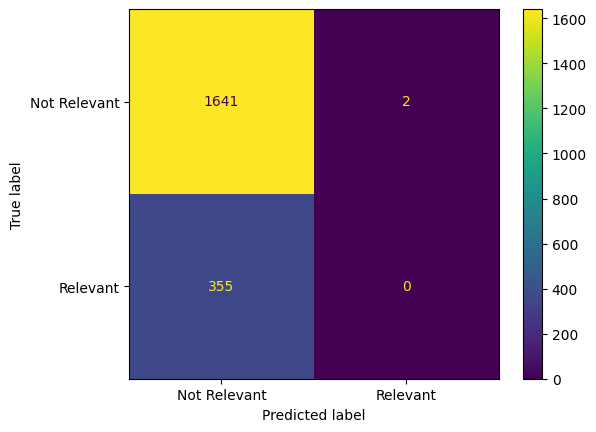

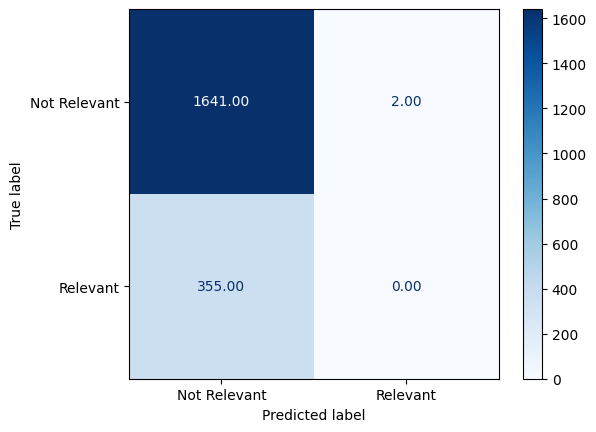

In [9]:
# Step 4: Evaluate the classifier using various measures
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_class, display_labels=['Not Relevant','Relevant'])
disp.plot(cmap='Blues', values_format='.2f')

print(classification_report(y_test, y_pred_class))